Device: cuda
Total: 6820 images | Classes: 150

exp1_resnet18_frozen
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 170MB/s] 


  [1/5] train_acc=0.158  val_acc=0.397  (41.8s)
  [2/5] train_acc=0.619  val_acc=0.611  (24.9s)
  [3/5] train_acc=0.792  val_acc=0.693  (23.8s)
  [4/5] train_acc=0.859  val_acc=0.755  (24.8s)
  [5/5] train_acc=0.901  val_acc=0.758  (25.6s)
  => Test Acc=0.7595  P=0.7823  R=0.7633  F1=0.7431


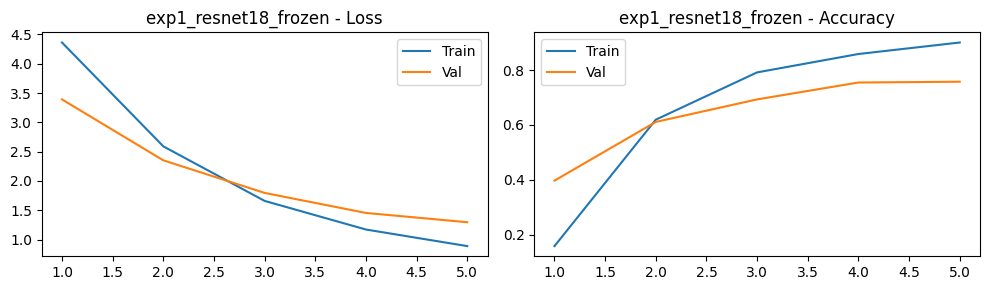


exp2_resnet18_full
  [1/5] train_acc=0.563  val_acc=0.700  (28.2s)
  [2/5] train_acc=0.904  val_acc=0.798  (27.4s)
  [3/5] train_acc=0.960  val_acc=0.849  (26.5s)
  [4/5] train_acc=0.976  val_acc=0.837  (25.7s)
  [5/5] train_acc=0.986  val_acc=0.907  (25.9s)
  => Test Acc=0.8993  P=0.9106  R=0.8972  F1=0.8915


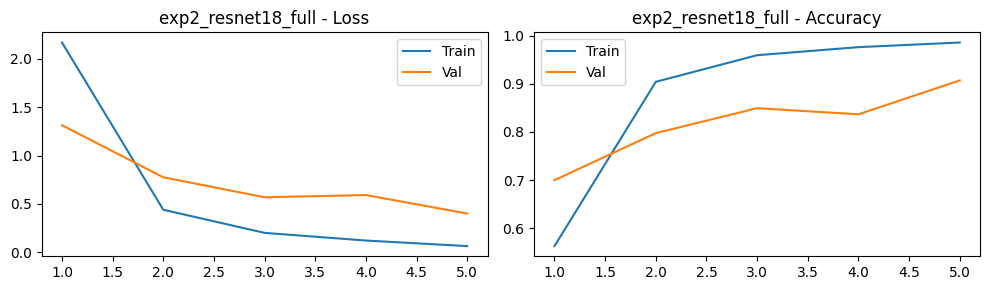


exp3_resnet50_frozen
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 217MB/s] 


  [1/5] train_acc=0.279  val_acc=0.516  (27.5s)
  [2/5] train_acc=0.817  val_acc=0.666  (27.6s)
  [3/5] train_acc=0.917  val_acc=0.711  (27.2s)
  [4/5] train_acc=0.953  val_acc=0.727  (27.4s)
  [5/5] train_acc=0.974  val_acc=0.752  (27.1s)
  => Test Acc=0.7771  P=0.7901  R=0.7833  F1=0.7663


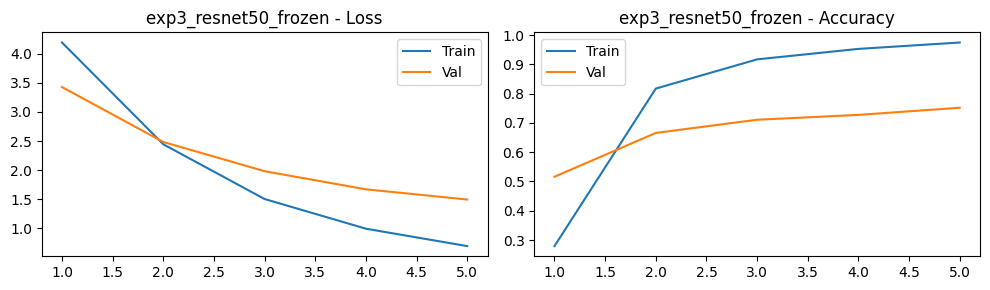


exp4_mobilenet_frozen
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 110MB/s] 


  [1/5] train_acc=0.236  val_acc=0.472  (24.5s)
  [2/5] train_acc=0.714  val_acc=0.635  (24.3s)
  [3/5] train_acc=0.832  val_acc=0.702  (23.7s)
  [4/5] train_acc=0.887  val_acc=0.728  (23.9s)
  [5/5] train_acc=0.918  val_acc=0.758  (23.9s)
  => Test Acc=0.7302  P=0.7553  R=0.7389  F1=0.7230


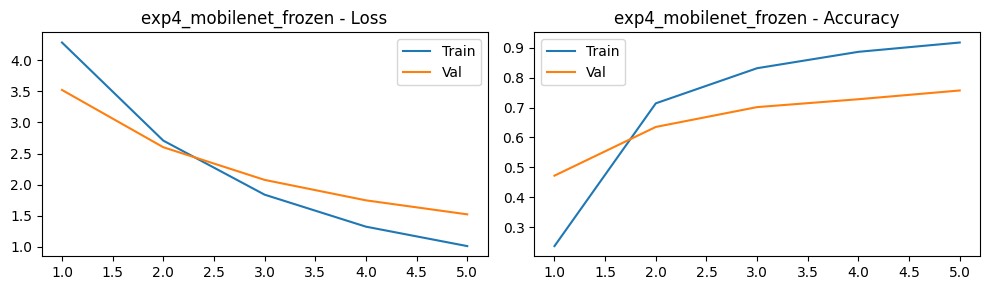


Experiment                      Acc   Prec    Rec     F1
-----------------------------------------------------------------
exp1_resnet18_frozen         0.7595 0.7823 0.7633 0.7431
exp2_resnet18_full           0.8993 0.9106 0.8972 0.8915
exp3_resnet50_frozen         0.7771 0.7901 0.7833 0.7663
exp4_mobilenet_frozen        0.7302 0.7553 0.7389 0.7230


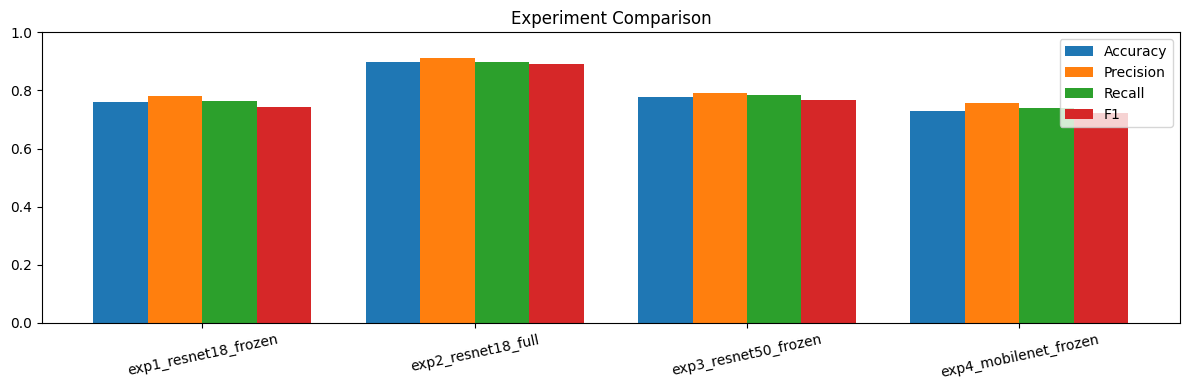


완료! 결과: /kaggle/working/results


In [3]:
import os, time, json, copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

# ── Config ──────────────────────────────────────────────────────
DATA_DIR   = "/kaggle/input/datasets/lantian773030/pokemonclassification/PokemonData"
OUTPUT_DIR = "/kaggle/working/results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

BATCH_SIZE = 64   # 크게 해서 빠르게
NUM_EPOCHS = 5    # 실험당 5 epoch
LR         = 1e-3
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ── Data ─────────────────────────────────────────────────────────
tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

full_dataset = datasets.ImageFolder(DATA_DIR, transform=tf)
NUM_CLASSES  = len(full_dataset.classes)
class_names  = full_dataset.classes
print(f"Total: {len(full_dataset)} images | Classes: {NUM_CLASSES}")

with open(f"{OUTPUT_DIR}/class_names.json", "w") as f:
    json.dump(class_names, f)

n_test  = int(len(full_dataset) * 0.15)
n_val   = int(len(full_dataset) * 0.15)
n_train = len(full_dataset) - n_val - n_test
train_set, val_set, test_set = random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)
val_set.dataset  = copy.deepcopy(full_dataset); val_set.dataset.transform  = val_tf
test_set.dataset = copy.deepcopy(full_dataset); test_set.dataset.transform = val_tf

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# ── Helpers ───────────────────────────────────────────────────────
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    loss_sum, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward(); optimizer.step()
        loss_sum += loss.item() * len(imgs)
        correct  += (out.argmax(1) == labels).sum().item()
        total    += len(imgs)
    return loss_sum/total, correct/total

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    loss_sum, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        out  = model(imgs)
        loss = criterion(out, labels)
        loss_sum += loss.item() * len(imgs)
        correct  += (out.argmax(1) == labels).sum().item()
        total    += len(imgs)
    return loss_sum/total, correct/total

@torch.no_grad()
def get_preds(model, loader):
    model.eval()
    ps, ls = [], []
    for imgs, labels in loader:
        ps.extend(model(imgs.to(DEVICE)).argmax(1).cpu().numpy())
        ls.extend(labels.numpy())
    return np.array(ls), np.array(ps)

# ── Experiment ────────────────────────────────────────────────────
def run(name, backbone, freeze):
    print(f"\n{'='*55}\n{name}\n{'='*55}")

    # build model
    if backbone == "resnet18":
        m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)
        if freeze:
            for n, p in m.named_parameters():
                if "fc" not in n: p.requires_grad = False
    elif backbone == "resnet50":
        m = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)
        if freeze:
            for n, p in m.named_parameters():
                if "fc" not in n: p.requires_grad = False
    elif backbone == "mobilenet":
        m = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, NUM_CLASSES)
        if freeze:
            for n, p in m.named_parameters():
                if "classifier" not in n: p.requires_grad = False
    m = m.to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, m.parameters()), lr=LR)

    history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}
    best_acc, best_state = 0, None

    for epoch in range(1, NUM_EPOCHS+1):
        t0 = time.time()
        tl, ta = train_epoch(m, train_loader, criterion, optimizer)
        vl, va = eval_epoch(m, val_loader, criterion)
        history["train_loss"].append(tl); history["val_loss"].append(vl)
        history["train_acc"].append(ta);  history["val_acc"].append(va)
        print(f"  [{epoch}/{NUM_EPOCHS}] train_acc={ta:.3f}  val_acc={va:.3f}  ({time.time()-t0:.1f}s)")
        if va > best_acc:
            best_acc, best_state = va, copy.deepcopy(m.state_dict())

    m.load_state_dict(best_state)
    y_true, y_pred = get_preds(m, test_loader)
    rep = classification_report(y_true, y_pred, target_names=class_names,
                                output_dict=True, zero_division=0)
    print(f"  => Test Acc={rep['accuracy']:.4f}  P={rep['macro avg']['precision']:.4f}  "
          f"R={rep['macro avg']['recall']:.4f}  F1={rep['macro avg']['f1-score']:.4f}")

    torch.save(best_state, f"{OUTPUT_DIR}/{name}.pth")

    # learning curve
    ep = range(1, NUM_EPOCHS+1)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    axes[0].plot(ep, history["train_loss"], label="Train"); axes[0].plot(ep, history["val_loss"], label="Val")
    axes[0].set_title(f"{name} - Loss"); axes[0].legend()
    axes[1].plot(ep, history["train_acc"], label="Train"); axes[1].plot(ep, history["val_acc"], label="Val")
    axes[1].set_title(f"{name} - Accuracy"); axes[1].legend()
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{name}_curve.png", dpi=100)
    plt.show(); plt.close()

    return {"experiment": name, "backbone": backbone, "freeze": freeze,
            "test_accuracy": rep["accuracy"],
            "test_precision": rep["macro avg"]["precision"],
            "test_recall": rep["macro avg"]["recall"],
            "test_f1": rep["macro avg"]["f1-score"]}

# ── 4 Experiments (총 ~10분) ──────────────────────────────────────
EXPERIMENTS = [
    ("exp1_resnet18_frozen",   "resnet18",   True),
    ("exp2_resnet18_full",     "resnet18",   False),
    ("exp3_resnet50_frozen",   "resnet50",   True),
    ("exp4_mobilenet_frozen",  "mobilenet",  True),
]

results = [run(name, bb, fr) for name, bb, fr in EXPERIMENTS]

# ── Summary table ─────────────────────────────────────────────────
print("\n" + "="*65)
print(f"{'Experiment':<28} {'Acc':>6} {'Prec':>6} {'Rec':>6} {'F1':>6}")
print("-"*65)
for r in results:
    print(f"{r['experiment']:<28} {r['test_accuracy']:>6.4f} "
          f"{r['test_precision']:>6.4f} {r['test_recall']:>6.4f} {r['test_f1']:>6.4f}")

# ── Comparison bar chart ──────────────────────────────────────────
names = [r["experiment"] for r in results]
x, w = np.arange(len(names)), 0.2
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x-1.5*w, [r["test_accuracy"]  for r in results], w, label="Accuracy")
ax.bar(x-0.5*w, [r["test_precision"] for r in results], w, label="Precision")
ax.bar(x+0.5*w, [r["test_recall"]    for r in results], w, label="Recall")
ax.bar(x+1.5*w, [r["test_f1"]        for r in results], w, label="F1")
ax.set_xticks(x); ax.set_xticklabels(names, rotation=12)
ax.set_ylim(0,1); ax.legend(); ax.set_title("Experiment Comparison")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/comparison.png", dpi=100)
plt.show(); plt.close()

with open(f"{OUTPUT_DIR}/summary.json", "w") as f:
    json.dump(results, f, indent=2)

print(f"\n완료! 결과: {OUTPUT_DIR}")


In [4]:
!pip install gradio -q

import gradio as gr
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import json

# 제일 좋은 모델 로드
with open("/kaggle/working/results/class_names.json") as f:
    class_names = json.load(f)

model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, len(class_names))
model.load_state_dict(torch.load("/kaggle/working/results/exp2_resnet18_full.pth"))
model.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

def predict(img):
    tensor = transform(img).unsqueeze(0)
    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1)[0]
    top5 = torch.topk(probs, 5)
    return {class_names[i]: float(p) for i, p in zip(top5.indices, top5.values)}

gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=5),
    title="Pokemon Classifier",
    description="포켓몬 이미지를 업로드하면 이름을 맞춰드립니다!",
).launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://1d42bbfa58e9bcd8b1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
